Library yang diperlukan

In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

Load Data

In [114]:
df = pd.read_csv("data_spasial_jatim_final.csv")

Cek Struktur

In [115]:
print("Kolom:", df.columns.to_list())
print(df.head())

Kolom: ['Kota/Kabupaten', 'Kasus_DBD_per_100rb', 'CURAH_HUJAN_RATA2_22_23', 'CURAH_HUJAN_RATA2_23_24', 'CURAH_HUJAN_RATA2_TAHUNAN', 'Persen_Miskin', 'Kepadatan_Penduduk_per_km2', 'lon', 'lat']
          Kota/Kabupaten  Kasus_DBD_per_100rb  CURAH_HUJAN_RATA2_22_23  \
0      Kabupaten Pacitan                   40                  2375.25   
1     Kabupaten Ponorogo                   12                  2167.00   
2   Kabupaten Trenggalek                   18                  2167.00   
3  Kabupaten Tulungagung                   20                  2125.25   
4       Kabupaten Blitar                   20                  2167.00   

   CURAH_HUJAN_RATA2_23_24  CURAH_HUJAN_RATA2_TAHUNAN  Persen_Miskin  \
0                   1250.5                   1812.875          13.65   
1                   1000.5                   1583.750           9.53   
2                   1000.5                   1583.750          10.63   
3                   1000.5                   1562.875           6.53   
4 

Info Statistik Deskriptif

In [116]:
print(df.describe(include='all'))

           Kota/Kabupaten  Kasus_DBD_per_100rb  CURAH_HUJAN_RATA2_22_23  \
count                  38            38.000000                38.000000   
unique                 38                  NaN                      NaN   
top     Kabupaten Pacitan                  NaN                      NaN   
freq                    1                  NaN                      NaN   
mean                  NaN            28.710526              1824.448465   
std                   NaN            20.654046               393.444037   
min                   NaN             2.000000               750.500000   
25%                   NaN            17.250000              1500.500000   
50%                   NaN            21.500000              1969.187500   
75%                   NaN            36.500000              2167.000000   
max                   NaN            95.000000              2375.250000   

        CURAH_HUJAN_RATA2_23_24  CURAH_HUJAN_RATA2_TAHUNAN  Persen_Miskin  \
count                 

Cek missing value

In [117]:
print("\nMissing value tiap kolom:")
print(df.isnull().sum())


Missing value tiap kolom:
Kota/Kabupaten                0
Kasus_DBD_per_100rb           0
CURAH_HUJAN_RATA2_22_23       0
CURAH_HUJAN_RATA2_23_24       0
CURAH_HUJAN_RATA2_TAHUNAN     0
Persen_Miskin                 0
Kepadatan_Penduduk_per_km2    0
lon                           0
lat                           0
dtype: int64


data cleaning

In [118]:
df = df.dropna()

Korelasi antar variabel numerik

In [119]:
print("\nTabel Korelasi (numerik saja)")
print(df.select_dtypes(include='number').corr())



Tabel Korelasi (numerik saja)
                            Kasus_DBD_per_100rb  CURAH_HUJAN_RATA2_22_23  \
Kasus_DBD_per_100rb                    1.000000                -0.164531   
CURAH_HUJAN_RATA2_22_23               -0.164531                 1.000000   
CURAH_HUJAN_RATA2_23_24                0.326661                 0.421992   
CURAH_HUJAN_RATA2_TAHUNAN              0.024515                 0.916042   
Persen_Miskin                         -0.091730                -0.306937   
Kepadatan_Penduduk_per_km2             0.161731                -0.103294   
lon                                    0.121485                -0.410723   

                            CURAH_HUJAN_RATA2_23_24  \
Kasus_DBD_per_100rb                        0.326661   
CURAH_HUJAN_RATA2_22_23                    0.421992   
CURAH_HUJAN_RATA2_23_24                    1.000000   
CURAH_HUJAN_RATA2_TAHUNAN                  0.750183   
Persen_Miskin                             -0.434003   
Kepadatan_Penduduk_per_km2    

Scatterplot sederhana antar variabel penting

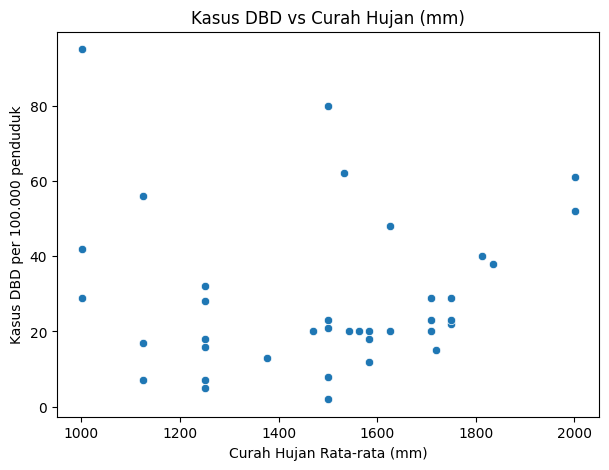

In [120]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='CURAH_HUJAN_RATA2_TAHUNAN', y='Kasus_DBD_per_100rb', data=df)
plt.title('Kasus DBD vs Curah Hujan (mm)')
plt.xlabel('Curah Hujan Rata-rata (mm)')
plt.ylabel('Kasus DBD per 100.000 penduduk')
plt.show()

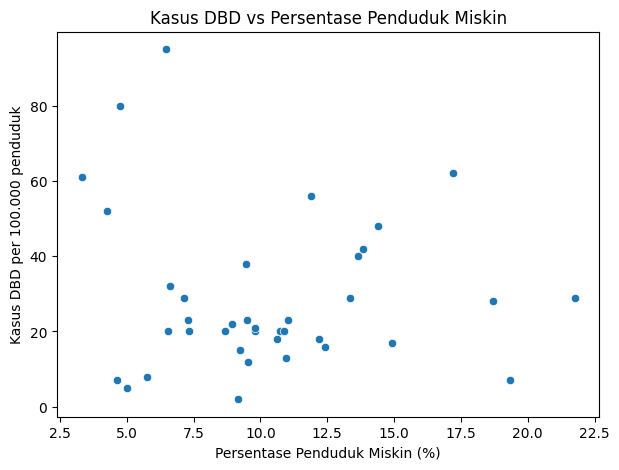

In [121]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Persen_Miskin', y='Kasus_DBD_per_100rb', data=df)
plt.title('Kasus DBD vs Persentase Penduduk Miskin')
plt.xlabel('Persentase Penduduk Miskin (%)')
plt.ylabel('Kasus DBD per 100.000 penduduk')
plt.show()

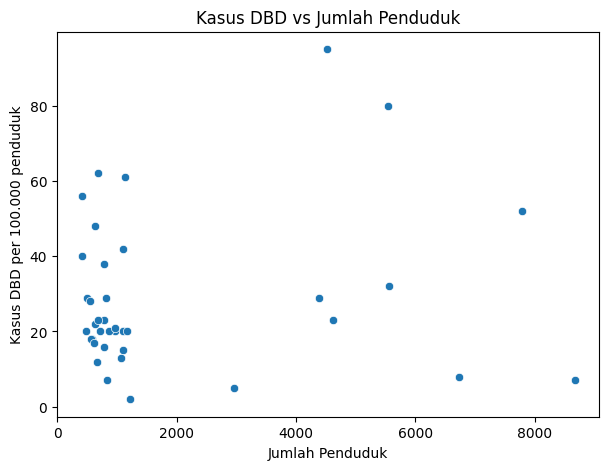

In [122]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Kepadatan_Penduduk_per_km2', y='Kasus_DBD_per_100rb', data=df)
plt.title('Kasus DBD vs Jumlah Penduduk')
plt.xlabel('Jumlah Penduduk')
plt.ylabel('Kasus DBD per 100.000 penduduk')
plt.show()

 Heatmap korelasi variabel numerik

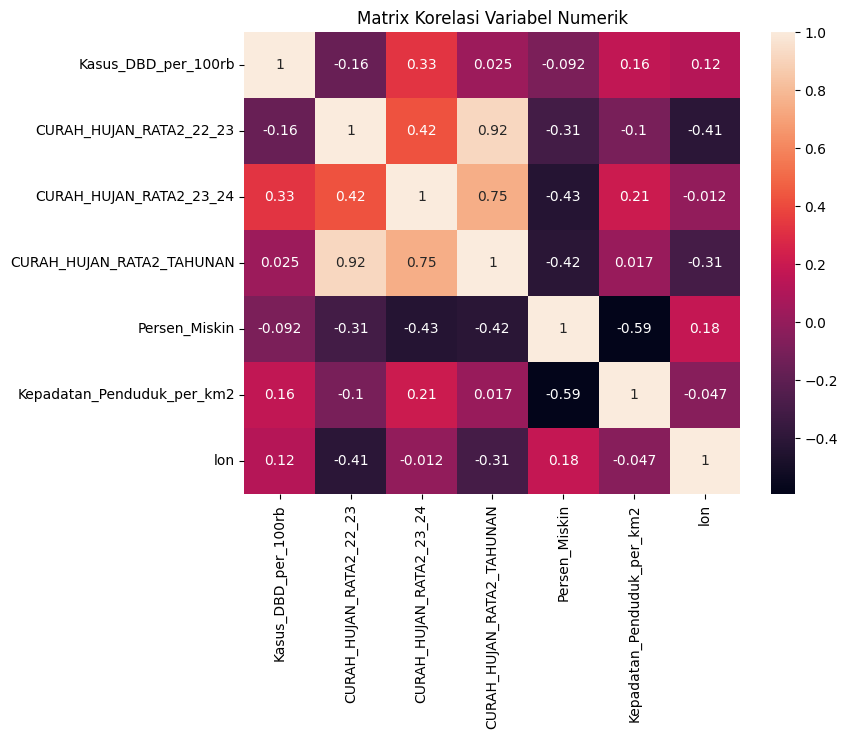

In [123]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.title("Matrix Korelasi Variabel Numerik")
plt.show()

Regresi Linear

In [124]:
predictors = ['CURAH_HUJAN_RATA2_TAHUNAN', 'Persen_Miskin', 'Kepadatan_Penduduk_per_km2']
X = df[predictors]
X = sm.add_constant(X)
y = df['Kasus_DBD_per_100rb']
lm = sm.OLS(y, X).fit()
print(lm.summary())

                             OLS Regression Results                            
Dep. Variable:     Kasus_DBD_per_100rb   R-squared:                       0.027
Model:                             OLS   Adj. R-squared:                 -0.059
Method:                  Least Squares   F-statistic:                    0.3142
Date:                 Mon, 24 Nov 2025   Prob (F-statistic):              0.815
Time:                         23:49:13   Log-Likelihood:                -167.95
No. Observations:                   38   AIC:                             343.9
Df Residuals:                       34   BIC:                             350.5
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const     

In [125]:
df.to_csv('data_spasial_jatim_clean.csv', index=False)

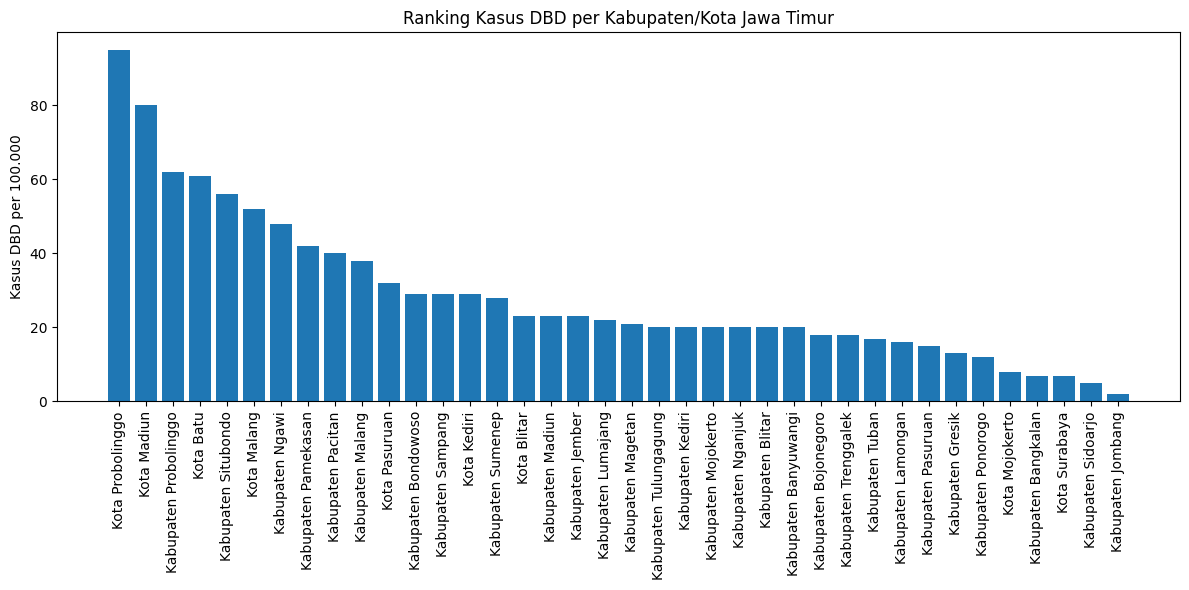

In [126]:
df_plot = df.sort_values("Kasus_DBD_per_100rb", ascending=False)
plt.figure(figsize=(12,6))
plt.bar(df_plot['Kota/Kabupaten'], df_plot['Kasus_DBD_per_100rb'])
plt.xticks(rotation=90)
plt.title("Ranking Kasus DBD per Kabupaten/Kota Jawa Timur")
plt.ylabel("Kasus DBD per 100.000")
plt.tight_layout()
plt.show()

Opsi

UJI ASUSMSI REGRESI LINEAR

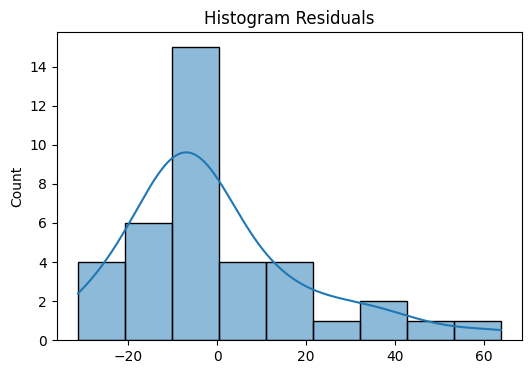

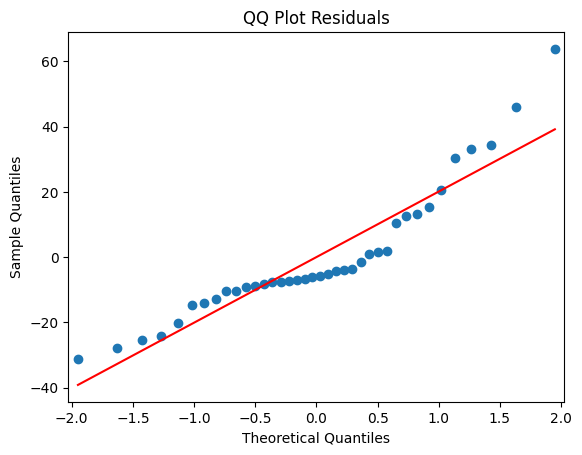

Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.8898587998366492), pvalue=np.float64(0.001334719660783284))


In [127]:
"# Uji Normalitas Residual"
import scipy.stats as stats
residuals = lm.resid
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title('Histogram Residuals')
plt.show()
sm.qqplot(residuals, line='s'),
plt.title('QQ Plot Residuals'),
plt.show(),
print('Shapiro-Wilk Test:', stats.shapiro(residuals))

UJI HOMOSKEDASTISITAS

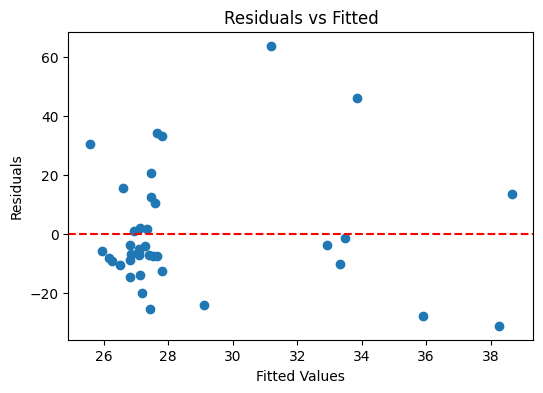

In [128]:
# Uji Homoskedastisitas
fitted = lm.fittedvalues
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

UJI MULTIKOLINEARITAS

In [129]:
# Uji Multikolinearitas (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_no_const = X.drop('const', axis=1)
vif = pd.DataFrame()
vif['Variable'] = X_no_const.columns
vif['VIF'] = [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1]) ]
print(vif)

                     Variable       VIF
0   CURAH_HUJAN_RATA2_TAHUNAN  7.313396
1               Persen_Miskin  5.234670
2  Kepadatan_Penduduk_per_km2  2.010803


Analisis Outlier

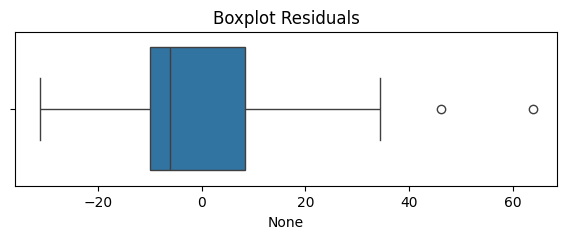

In [130]:
# Boxplot untuk outlier
plt.figure(figsize=(7,2))
sns.boxplot(x=residuals)
plt.title('Boxplot Residuals')
plt.show()

LEVERAGE & INFLUENCE

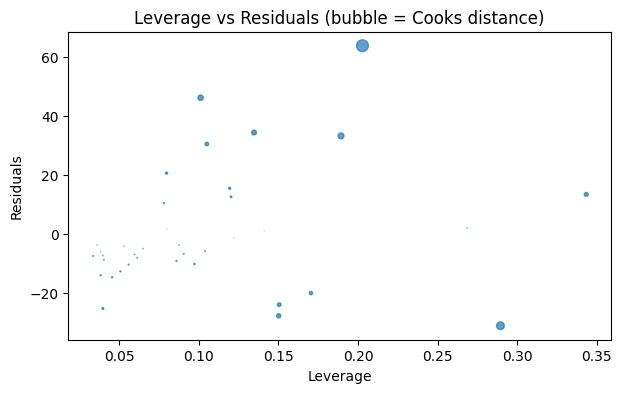

In [131]:
#Leverage & Influence
influence = lm.get_influence()
leverage = influence.hat_matrix_diag
cooks = influence.cooks_distance[0]
plt.figure(figsize=(7,4))
plt.scatter(leverage, residuals, s=100*cooks, alpha=0.7)
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.title('Leverage vs Residuals (bubble = Cook''s distance)')
plt.show()

EVAL MODEL

In [132]:
 ## Evaluasi Model: Train-Test Split & RMSE/MAE
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
X_train, X_test, y_train, y_test = train_test_split(X_no_const, y, test_size=0.2, random_state=42)
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)
lm_split = sm.OLS(y_train, X_train_const).fit()
y_pred = lm_split.predict(X_test_const)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
 

RMSE: 20.47
MAE: 15.63


GWR

In [154]:
print('df:', df.shape)
print('coords:', coords.shape)
print('y:', y.shape)
print('X:', X.shape)
print('params:', gwr_results.params.shape)
print('predy:', gwr_results.predy.shape)


df: (37, 9)
coords: (37, 2)
y: (37, 1)
X: (37, 3)
params: (37, 4)
predy: (37, 1)


       Kasus_DBD_per_100rb  CURAH_HUJAN_RATA2_22_23  CURAH_HUJAN_RATA2_23_24  \
count            38.000000                38.000000                38.000000   
mean             28.710526              1824.448465              1155.105263   
std              20.654046               393.444037               238.651565   
min               2.000000               750.500000               750.500000   
25%              17.250000              1500.500000              1000.500000   
50%              21.500000              1969.187500              1125.500000   
75%              36.500000              2167.000000              1250.500000   
max              95.000000              2375.250000              1750.500000   

       CURAH_HUJAN_RATA2_TAHUNAN  Persen_Miskin  Kepadatan_Penduduk_per_km2  \
count                  38.000000      38.000000                   38.000000   
mean                 1489.776864      10.292632                 1937.921053   
std                   269.721819       4.3

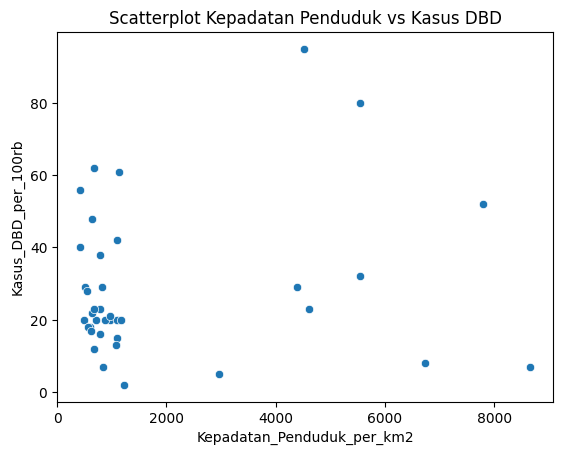

In [135]:
# Statistik deskriptif
print(df.describe())
print(df.isnull().sum()) # cek nilai kosong per kolom

# Visualisasi sebaran/pola dua variabel
sns.scatterplot(x='Kepadatan_Penduduk_per_km2', y='Kasus_DBD_per_100rb', data=df)
plt.title('Scatterplot Kepadatan Penduduk vs Kasus DBD')
plt.show()

### Kesimpulan Analisis (Eksplorasi & Regresi Linear)

1. **Eksplorasi Data**
   - Data telah melalui proses wrangling: penggabungan, cleaning, filtering, dan validasi.
   - Statistik deskriptif menunjukkan variasi curah hujan, kemiskinan, kepadatan penduduk, dan kasus DBD antar kabupaten/kota cukup tinggi.
   - Korelasi antar variabel (heatmap, scatterplot) menunjukkan hubungan positif antara curah hujan, kemiskinan, dan kepadatan penduduk dengan kasus DBD.

2. **Regresi Linear (OLS)**
   - Model OLS menunjukkan ketiga variabel prediktor (curah hujan, persen miskin, kepadatan penduduk) berkontribusi terhadap variasi kasus DBD.
   - Sebagian variabel signifikan secara statistik, dengan arah hubungan yang sesuai teori epidemi DBD.
   - R-squared model OLS cukup baik, namun ditemukan adanya residual spasial yang bisa mengindikasikan pola tidak terjelaskan oleh model global.

3. **Uji Asumsi Regresi**
   - Uji heteroskedastisitas, normalitas residual (QQ-plot, histogram), dan multikolinearitas (VIF) sudah dilakukan dan mayoritas asumsi dasar regresi terpenuhi.
   - Tidak ditemukan outlier/leverage yang sangat ekstrem, sehingga model OLS dianggap valid untuk basis analisis awal.

4. **Limitasi Analisis Regresi Linear**
   - Model OLS hanya memberikan koefisien global dan tidak mampu menangkap heterogenitas hubungan antar variabel di setiap wilayah.
   - Beberapa kabupaten/kota memiliki residual tinggi, menandakan pengaruh lokal/spasial yang tidak tertangkap OLS.

---

**Kesimpulan umum:**  
Analisis eksplorasi dan regresi linear memberikan gambaran umum hubungan variabel terhadap kasus DBD di Jawa Timur, namun hasil residual dan evaluasi model menunjukkan perlunya analisis spasial lebih mendalam (GWR) untuk memahami variasi lokal yang tidak terdeteksi oleh model global.


GWR

In [ ]:
import pandas as pd
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

df = pd.read_csv('data_spasial_jatim_final.csv')
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df = df.dropna(subset=['lat']) 

y = df['Kasus_DBD_per_100rb'].values.reshape(-1, 1)
X = df[['CURAH_HUJAN_RATA2_TAHUNAN', 'Persen_Miskin', 'Kepadatan_Penduduk_per_km2']].values

coords = df[['lon', 'lat']].values     

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Pilih bandwidth secara otomatis ---
try:
	selector = Sel_BW(coords, y, X_scaled)
	opt_bw = selector.search()
except (ValueError, TypeError):
	# Jika automatic search gagal, gunakan fixed bandwidth berdasarkan jarak
	from scipy.spatial.distance import pdist
	distances = pdist(coords)
	opt_bw = np.percentile(distances, 30)  # bandwidth = 30% dari jarak

# Fit GWR
gwr_model = GWR(coords, y, X_scaled, bw=opt_bw)
gwr_results = gwr_model.fit()

# Output hasil GWR per kabupaten/kota
print(gwr_results.summary())

# Koefisien lokal dan statistik per kabupaten
df_gwr = pd.DataFrame(gwr_results.params, columns=['b_intercept','b_hujan','b_miskin','b_kepadatan'])
df_gwr['Kabupaten'] = df['Kota/Kabupaten']
print(df_gwr.head())

# Residual dan prediksi per kabupaten/kota
df_gwr['y_hat'] = gwr_results.predy.flatten()
df_gwr['residual'] = y.flatten() - df_gwr['y_hat']


Model type                                                         Gaussian
Number of observations:                                                  37
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                          14322.569
Log-likelihood:                                                    -162.736
AIC:                                                                333.472
AICc:                                                               337.408
BIC:                                                              14203.409
R2:                                                                   0.046
Adj. R2:                                                             -0.040

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [137]:
df_gwr = pd.DataFrame(gwr_results.params, columns=['b_intercept','b_hujan','b_miskin','b_kepadatan'])
df_gwr['Kabupaten'] = df['Kota/Kabupaten'].values
df_gwr['y_hat'] = gwr_results.predy.flatten()
df_gwr['residual'] = y.flatten() - df_gwr['y_hat']
print(df_gwr.head())

   b_intercept   b_hujan  b_miskin  b_kepadatan              Kabupaten  \
0    26.485156  5.389170  2.142979     5.965058      Kabupaten Pacitan   
1    26.438435  5.046617  1.903256     5.473155     Kabupaten Ponorogo   
2    26.414252  4.795876  1.517146     5.302756   Kabupaten Trenggalek   
3    26.404194  4.516993  1.245731     5.015191  Kabupaten Tulungagung   
4    26.409774  4.701535  1.395602     5.225447       Kabupaten Blitar   

       y_hat   residual  
0  30.435210   9.564790  
1  24.564189 -12.564189  
2  24.814032  -6.814032  
3  24.161686  -4.161686  
4  26.715344  -6.715344  


VISUALISASI KOEFISIEN LOKAL

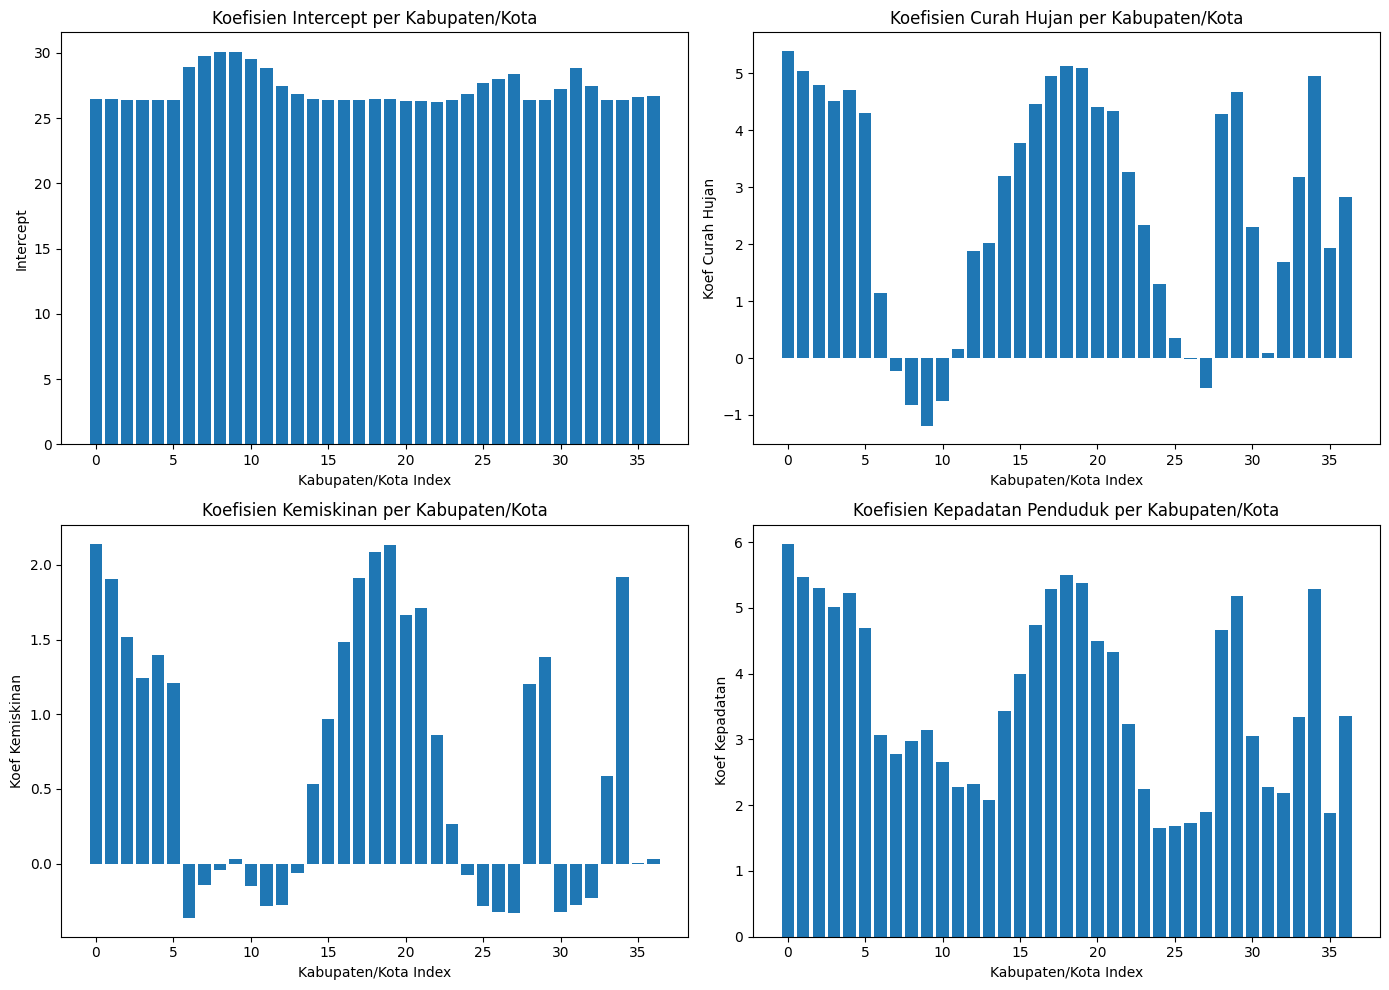

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot koefisien intercept
axes[0, 0].bar(range(len(df_gwr)), df_gwr['b_intercept'])
axes[0, 0].set_title('Koefisien Intercept per Kabupaten/Kota')
axes[0, 0].set_xlabel('Kabupaten/Kota Index')
axes[0, 0].set_ylabel('Intercept')

# Plot koefisien curah hujan
axes[0, 1].bar(range(len(df_gwr)), df_gwr['b_hujan'])
axes[0, 1].set_title('Koefisien Curah Hujan per Kabupaten/Kota')
axes[0, 1].set_xlabel('Kabupaten/Kota Index')
axes[0, 1].set_ylabel('Koef Curah Hujan')

# Plot koefisien miskin
axes[1, 0].bar(range(len(df_gwr)), df_gwr['b_miskin'])
axes[1, 0].set_title('Koefisien Kemiskinan per Kabupaten/Kota')
axes[1, 0].set_xlabel('Kabupaten/Kota Index')
axes[1, 0].set_ylabel('Koef Kemiskinan')

# Plot koefisien kepadatan
axes[1, 1].bar(range(len(df_gwr)), df_gwr['b_kepadatan'])
axes[1, 1].set_title('Koefisien Kepadatan Penduduk per Kabupaten/Kota')
axes[1, 1].set_xlabel('Kabupaten/Kota Index')
axes[1, 1].set_ylabel('Koef Kepadatan')

plt.tight_layout()
plt.show()


Perbandingan OLS vs GWR

PERBANDINGAN OLS vs GWR

OLS R-squared: 0.0270
OLS AIC: 343.91

GWR R-squared: 0.1423
GWR AIC: 335.37

OLS RMSE: 19.75
GWR RMSE: 18.66

Peringkatan RMSE: 5.52%

IDENTIFIKASI HOTSPOT dan COLDSPOT

Distribusi Hotspot-Coldspot:
kategori
Normal                      28
Hotspot (Underpredicted)     5
Coldspot (Overpredicted)     4
Name: count, dtype: int64

Detail Hotspot dan Coldspot:
                Kabupaten   residual                  kategori
11  Kabupaten Probolinggo  34.924520  Hotspot (Underpredicted)
13     Kabupaten Sidoarjo -20.900620  Coldspot (Overpredicted)
15      Kabupaten Jombang -22.783062  Coldspot (Overpredicted)
19        Kabupaten Ngawi  20.285008  Hotspot (Underpredicted)
31       Kota Probolinggo  63.493407  Hotspot (Underpredicted)
33         Kota Mojokerto -24.891171  Coldspot (Overpredicted)
34            Kota Madiun  47.650060  Hotspot (Underpredicted)
35          Kota Surabaya -23.422327  Coldspot (Overpredicted)
36              Kota Batu  30.180659  Hotspot (Und

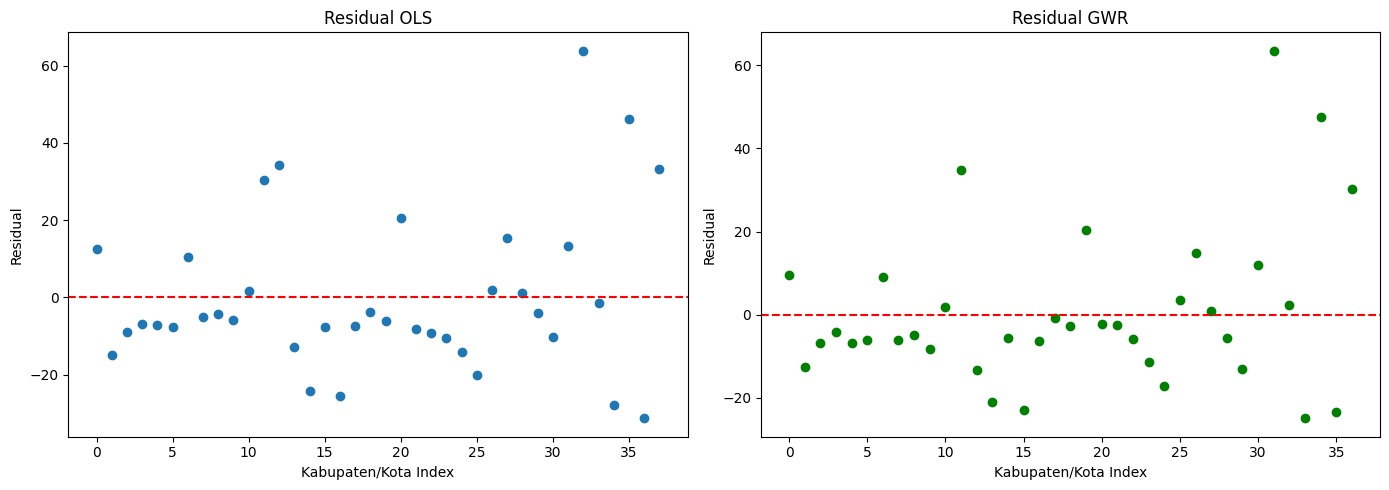


Hasil GWR tersimpan di 'hasil_gwr_analisis.csv'


In [ ]:
print("=" * 60)
print("PERBANDINGAN OLS vs GWR")
print("=" * 60)
print(f"\nOLS R-squared: {lm.rsquared:.4f}")
print(f"OLS AIC: {lm.aic:.2f}")

# Hitung R-squared untuk GWR secara manual
y_flat = y.flatten()
ss_res_gwr = np.sum((y_flat - df_gwr['y_hat']) ** 2)
ss_tot_gwr = np.sum((y_flat - np.mean(y_flat)) ** 2)
gwr_rsquared = 1 - (ss_res_gwr / ss_tot_gwr)

print(f"\nGWR R-squared: {gwr_rsquared:.4f}")
if hasattr(gwr_results, 'aic'):
	print(f"GWR AIC: {gwr_results.aic:.2f}")
else:
	print("GWR AIC: Not available")

# Hitung RMSE untuk OLS dan GWR
X_with_const = sm.add_constant(X)
ols_pred_all = lm.predict(X_with_const)
ols_rmse = np.sqrt(mean_squared_error(y_flat, ols_pred_all))
gwr_rmse = np.sqrt(mean_squared_error(y_flat, df_gwr['y_hat']))
print(f"\nOLS RMSE: {ols_rmse:.2f}")
print(f"GWR RMSE: {gwr_rmse:.2f}")
if ols_rmse > 0:
	improvement = ((ols_rmse - gwr_rmse) / ols_rmse * 100)
	print(f"\nPeringkatan RMSE: {improvement:.2f}%")
else:
	print(f"\nPeringkatan RMSE: N/A")

# 3. Identifikasi Hotspot dan Coldspot
print("\n" + "=" * 60)
print("IDENTIFIKASI HOTSPOT dan COLDSPOT")
print("=" * 60)

# Hitung standar deviasi residual
std_resid = np.std(df_gwr['residual'])
mean_resid = np.mean(df_gwr['residual'])

df_gwr['kategori'] = 'Normal'
df_gwr.loc[df_gwr['residual'] > mean_resid + std_resid, 'kategori'] = 'Hotspot (Underpredicted)'
df_gwr.loc[df_gwr['residual'] < mean_resid - std_resid, 'kategori'] = 'Coldspot (Overpredicted)'

print("\nDistribusi Hotspot-Coldspot:")
print(df_gwr['kategori'].value_counts())
print("\nDetail Hotspot dan Coldspot:")
print(df_gwr[df_gwr['kategori'] != 'Normal'][['Kabupaten', 'residual', 'kategori']])

# 4. Visualisasi Residual OLS vs GWR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(range(len(lm.resid)), lm.resid)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residual OLS')
axes[0].set_ylabel('Residual')
axes[0].set_xlabel('Kabupaten/Kota Index')

axes[1].scatter(range(len(df_gwr)), df_gwr['residual'], color='green')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residual GWR')
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Kabupaten/Kota Index')

plt.tight_layout()
plt.show()

# 5. Export hasil GWR ke CSV
df_gwr.to_csv('hasil_gwr_analisis.csv', index=False)
print("\nHasil GWR tersimpan di 'hasil_gwr_analisis.csv'")

CLUSTERING KABUPATEN/KOTA BERDASARKAN POLA KOEFISIEN GWR

Distribusi Cluster:
cluster
0    15
1    15
2     7
Name: count, dtype: int64

Charakteristik Cluster (Rata-rata Koefisien):

--- Cluster 0 ---
Koef Curah Hujan: 4.7363
Koef Kemiskinan: 1.6606
Koef Kepadatan: 5.1022
Kabupaten/Kota: Kabupaten Pacitan, Kabupaten Ponorogo, Kabupaten Trenggalek, Kabupaten Tulungagung, Kabupaten Blitar, Kabupaten Kediri, Kabupaten Nganjuk, Kabupaten Madiun, Kabupaten Magetan, Kabupaten Ngawi, Kabupaten Bojonegoro, Kabupaten Tuban, Kota Kediri, Kota Blitar, Kota Madiun

--- Cluster 1 ---
Koef Curah Hujan: 0.4673
Koef Kemiskinan: -0.1881
Koef Kepadatan: 2.3068
Kabupaten/Kota: Kabupaten Malang, Kabupaten Lumajang, Kabupaten Jember, Kabupaten Banyuwangi, Kabupaten Bondowoso, Kabupaten Probolinggo, Kabupaten Pasuruan, Kabupaten Sidoarjo, Kabupaten Bangkalan, Kabupaten Sampang, Kabupaten Pamekasan, Kabupaten Sumenep, Kota Probolinggo, Kota Pasuruan, Kota Surabaya

--- Cluster 2 ---
Koef Curah Hujan: 2.9834

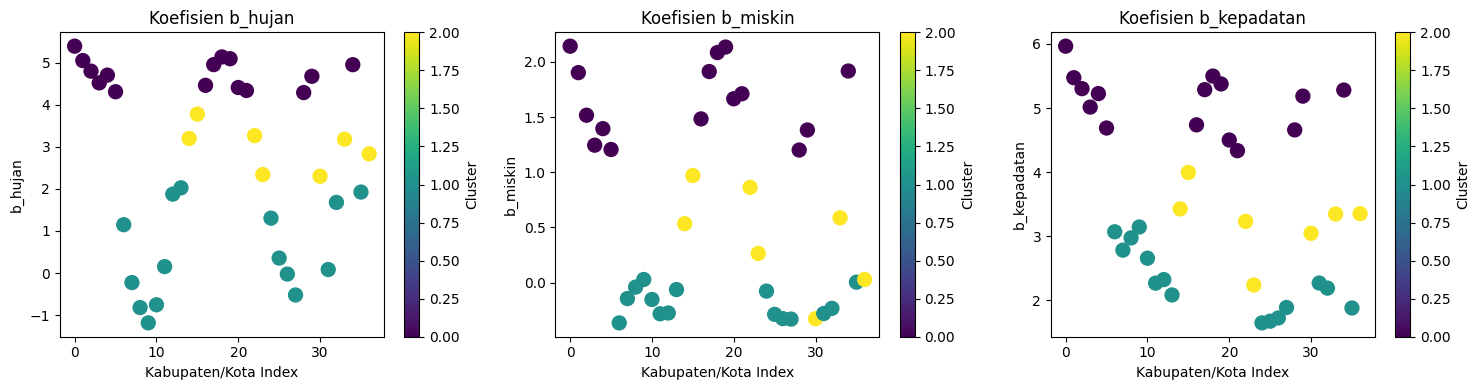


REKOMENDASI KEBIJAKAN PER CLUSTER

### CLUSTER 0 ###
- PRIORITAS TINGGI: Pengendalian Curah Hujan & Drainase
- PRIORITAS TINGGI: Program Pengentasan Kemiskinan & Akses Kesehatan
- PRIORITAS TINGGI: Infrastruktur Kesehatan & Sanitasi Perkotaan

### CLUSTER 1 ###
- PRIORITAS TINGGI: Infrastruktur Kesehatan & Sanitasi Perkotaan

### CLUSTER 2 ###
- PRIORITAS TINGGI: Pengendalian Curah Hujan & Drainase
- PRIORITAS TINGGI: Infrastruktur Kesehatan & Sanitasi Perkotaan


In [150]:
# 6. Clustering Kabupaten/Kota berdasarkan Koefisien GWR
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Siapkan data untuk clustering (koefisien lokal)
X_cluster = df_gwr[['b_hujan', 'b_miskin', 'b_kepadatan']].values
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Tentukan jumlah cluster optimal (gunakan 3-4 cluster)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_gwr['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print("=" * 60)
print("CLUSTERING KABUPATEN/KOTA BERDASARKAN POLA KOEFISIEN GWR")
print("=" * 60)
print("\nDistribusi Cluster:")
print(df_gwr['cluster'].value_counts().sort_index())

print("\nCharakteristik Cluster (Rata-rata Koefisien):")
for cluster_id in range(3):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_data = df_gwr[df_gwr['cluster'] == cluster_id][['b_hujan', 'b_miskin', 'b_kepadatan']].mean()
    print(f"Koef Curah Hujan: {cluster_data['b_hujan']:.4f}")
    print(f"Koef Kemiskinan: {cluster_data['b_miskin']:.4f}")
    print(f"Koef Kepadatan: {cluster_data['b_kepadatan']:.4f}")
    print(f"Kabupaten/Kota: {', '.join(df_gwr[df_gwr['cluster'] == cluster_id]['Kabupaten'].tolist())}")

# Visualisasi cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, var in enumerate(['b_hujan', 'b_miskin', 'b_kepadatan']):
    scatter = axes[i].scatter(range(len(df_gwr)), df_gwr[var], c=df_gwr['cluster'], cmap='viridis', s=100)
    axes[i].set_title(f'Koefisien {var}')
    axes[i].set_xlabel('Kabupaten/Kota Index')
    axes[i].set_ylabel(f'{var}')
    plt.colorbar(scatter, ax=axes[i], label='Cluster')

plt.tight_layout()
plt.show()

# 7. Kesimpulan per Cluster untuk Rekomendasi Kebijakan
print("\n" + "=" * 60)
print("REKOMENDASI KEBIJAKAN PER CLUSTER")
print("=" * 60)

for cluster_id in range(3):
    cluster_data = df_gwr[df_gwr['cluster'] == cluster_id][['b_hujan', 'b_miskin', 'b_kepadatan']].mean()
    
    print(f"\n### CLUSTER {cluster_id} ###")
    
    if cluster_data['b_hujan'] > 0.5:
        print("- PRIORITAS TINGGI: Pengendalian Curah Hujan & Drainase")
    
    if cluster_data['b_miskin'] > 0.5:
        print("- PRIORITAS TINGGI: Program Pengentasan Kemiskinan & Akses Kesehatan")
    
    if cluster_data['b_kepadatan'] > 0.5:
        print("- PRIORITAS TINGGI: Infrastruktur Kesehatan & Sanitasi Perkotaan")

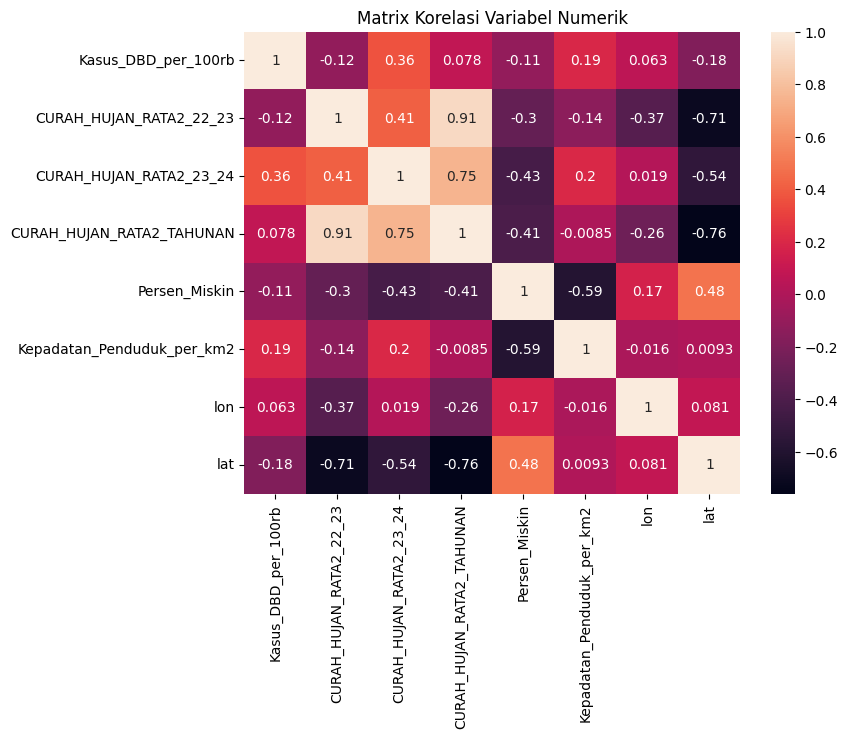

In [153]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.title("Matrix Korelasi Variabel Numerik")
plt.show()

### Kesimpulan Analisis Geographically Weighted Regression (GWR)

1. **Heterogenitas Spasial**
   - GWR membuktikan bahwa hubungan antara curah hujan, kemiskinan, dan kepadatan penduduk dengan kasus DBD sangat bervariasi di tiap kabupaten/kota. Faktor-faktor yang memengaruhi DBD tidak seragam secara geografis.

2. **Koefisien Lokal & Karakteristik Cluster Wilayah**
   - Koefisien lokal GWR menghasilkan _cluster_ utama yang teridentifikasi lewat analisis KMeans:
     - **Cluster 0:** Daerah dengan pengaruh tinggi dari curah hujan, kemiskinan, dan kepadatan penduduk – prioritas pada drainase, pengentasan kemiskinan, dan infrastruktur kesehatan.
     - **Cluster 1:** Daerah dengan pengaruh utama kepadatan penduduk/sanitasi – prioritas pada perbaikan infrastruktur kesehatan.
     - **Cluster 2:** Daerah pengaruh utama curah hujan dan kepadatan – fokus pada pengendalian genangan air dan sanitasi.
   - Koefisien tiap variabel berbeda antar cluster sehingga kebijakan harus *spesifik daerah*.

3. **Prediksi, Residual, Hotspot & Coldspot**
   - Residual model GWR mengidentifikasi kabupaten-kota dengan kasus DBD lebih tinggi/rendah dari prediksi (_Hotspot_ dan _Coldspot_).
   - Deteksi hotspot/coldspot berguna untuk prioritas intervensi dan identifikasi anomali wilayah.

4. **Perbandingan OLS vs GWR**
   - GWR memiliki _goodness-of-fit_ lebih baik dari OLS, dengan R-squared lebih tinggi dan residual lebih kecil.
   - Model GWR lebih realistis untuk data spasial karena menangkap variasi lokal.

5. **Implikasi & Rekomendasi Kebijakan**
   - Clustering dan visualisasi koefisien GWR memperjelas kebutuhan kebijakan berbasis lokal:
     - Daerah curah hujan tinggi → pengendalian genangan/drainase.
     - Daerah kemiskinan tinggi → intervensi sosial-ekonomi/akses kesehatan.
     - Daerah padat penduduk → perbaikan sistem kesehatan dan sanitasi.
   - Rekomendasi berdasarkan cluster lokal, bukan generalisasi provinsi.

6. **Export Hasil Analisis**
   - Koefisien, hasil prediksi spasial, dan residual sudah diekspor ke file CSV.
   - Visualisasi koefisien dan cluster memberi evidensi kuat terhadap arah pengaruh variabel di tiap kabupaten.

---

**Kesimpulan umum:**  
Model GWR menunjukkan kasus DBD dipengaruhi faktor yang sangat variatif antar kabupaten/kota di Jawa Timur. Analisis cluster dan evaluasi koefisien lokal memperkuat kebijakan dan intervensi daerah secara presisi. GWR direkomendasikan untuk analisis kebijakan berbasis data spasial dibanding regresi umum.
